In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import joblib

#Load data
df = pd.read_csv(r"D:/datasets/titanic/train.csv")  

In [2]:
#Feature engineering & preprocessing 
def extract_title(name):
    # extract title (Mr, Mrs, Miss, etc.)
    if pd.isnull(name):
        return "Unknown"
    # name like "Braund, Mr. Owen Harris"
    parts = name.split(',')
    if len(parts) > 1:
        title_part = parts[1]
        title = title_part.split('.')[0].strip()
        return title
    return "Unknown"

df['Title'] = df['Name'].apply(extract_title)
# group rare titles
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
}
df['Title'] = df['Title'].replace(title_map)
rare_titles = df['Title'].value_counts()
rare = rare_titles[rare_titles < 10].index
df['Title'] = df['Title'].replace(list(rare), 'Rare')

# Cabin: presence indicator (has cabin info)
df['HasCabin'] = (~df['Cabin'].isna()).astype(int)

# Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Fill missing Embarked with most common
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Choose features
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'HasCabin', 'FamilySize']
X = df[features]
y = df['Survived']

# Preprocessing pipelines
numeric_features = ['Age', 'Fare', 'FamilySize']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'HasCabin']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)



In [3]:
# -------------- Decision Tree: grid search --------------
dt_pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'clf__max_depth': [3, 4, 5, 6, 8, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 4, 8]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_dt.fit(X, y)

print("Best DT params:", grid_dt.best_params_)
print("Best DT CV accuracy (on folds used inside GridSearch):", grid_dt.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best DT params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Best DT CV accuracy (on folds used inside GridSearch): 0.8226413909986817


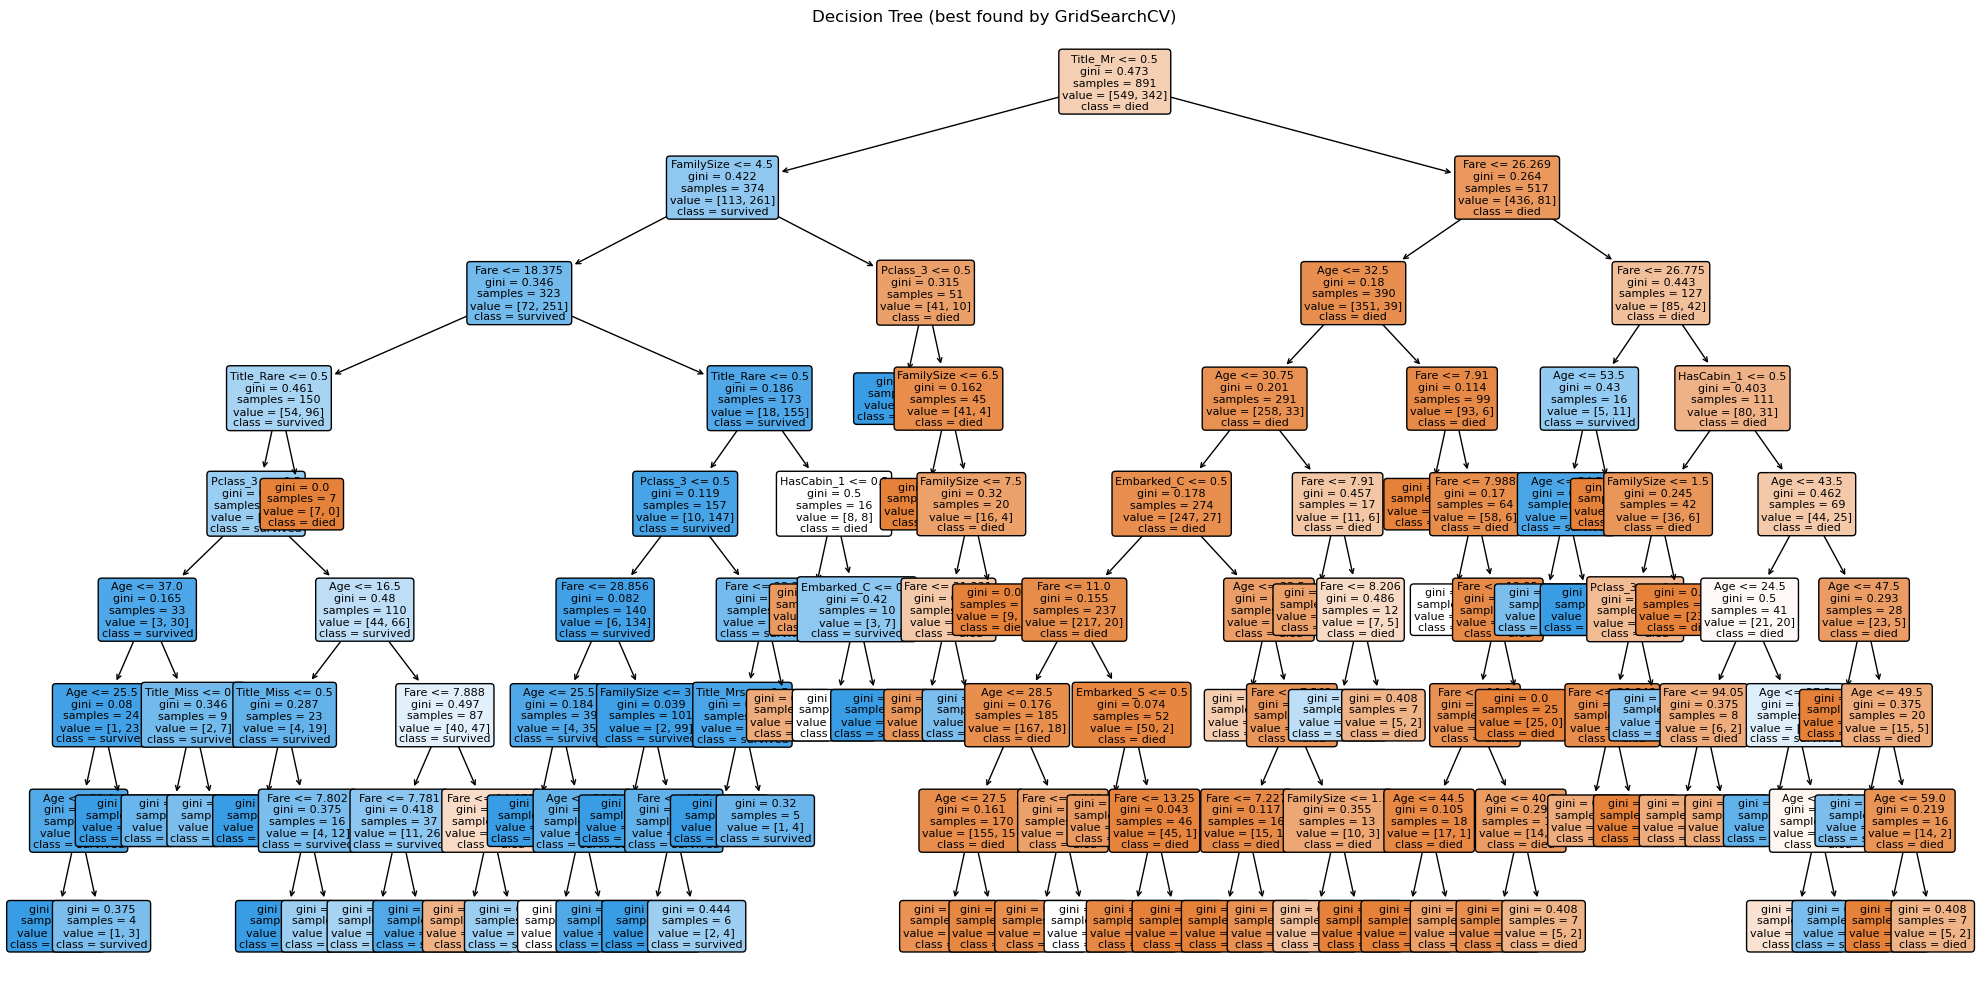

|--- Title_Mr <= 0.50
|   |--- FamilySize <= 4.50
|   |   |--- Fare <= 18.38
|   |   |   |--- Title_Rare <= 0.50
|   |   |   |   |--- Pclass_3 <= 0.50
|   |   |   |   |   |--- Age <= 37.00
|   |   |   |   |   |   |--- Age <= 25.50
|   |   |   |   |   |   |   |--- Age <= 22.00
|   |   |   |   |   |   |   |   |--- weights: [0.00, 5.00] class: 1
|   |   |   |   |   |   |   |--- Age >  22.00
|   |   |   |   |   |   |   |   |--- weights: [1.00, 3.00] class: 1
|   |   |   |   |   |   |--- Age >  25.50
|   |   |   |   |   |   |   |--- weights: [0.00, 15.00] class: 1
|   |   |   |   |   |--- Age >  37.00
|   |   |   |   |   |   |--- Title_Miss <= 0.50
|   |   |   |   |   |   |   |--- weights: [1.00, 4.00] class: 1
|   |   |   |   |   |   |--- Title_Miss >  0.50
|   |   |   |   |   |   |   |--- weights: [1.00, 3.00] class: 1
|   |   |   |   |--- Pclass_3 >  0.50
|   |   |   |   |   |--- Age <= 16.50
|   |   |   |   |   |   |--- Title_Miss <= 0.50
|   |   |   |   |   |   |   |--- weights: [0.00,

['best_decision_tree_pipeline.joblib']

In [4]:
#Plot the decision tree (best estimator)
best_dt = grid_dt.best_estimator_.named_steps['clf']
# Need to get preprocessed feature names after one-hot encoding
onehot = grid_dt.best_estimator_.named_steps['preproc'].transformers_[1][1].named_steps['onehot']
cat_cols = onehot.get_feature_names_out(categorical_features)
feat_names = numeric_features + list(cat_cols)

plt.figure(figsize=(20,10))
plot_tree(best_dt, feature_names=feat_names, class_names=['died','survived'], filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (best found by GridSearchCV)")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=200)
plt.show()

# Optionally export textual tree
r = export_text(best_dt, feature_names=feat_names, show_weights=True)
print(r)

# Save model
joblib.dump(grid_dt.best_estimator_, "best_decision_tree_pipeline.joblib")

In [5]:
# -------------- 5-fold CV accuracy for tuned Decision Tree --------------
dt_tuned = grid_dt.best_estimator_  # includes preprocessing
scores_dt = cross_val_score(dt_tuned, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print("Decision Tree 5-fold CV accuracies:", scores_dt)
print("Decision Tree 5-fold CV mean accuracy:", scores_dt.mean())

Decision Tree 5-fold CV accuracies: [0.84916201 0.8258427  0.7752809  0.84269663 0.82022472]
Decision Tree 5-fold CV mean accuracy: 0.8226413909986817


In [6]:
# -------------- Random Forest: tuned via GridSearch or use sensible defaults --------------
rf_pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 8, None],
    'clf__max_features': ['sqrt', 0.5, None],
    'clf__min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf.fit(X, y)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV accuracy (on folds used inside GridSearch):", grid_rf.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best RF params: {'clf__max_depth': None, 'clf__max_features': None, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 200}
Best RF CV accuracy (on folds used inside GridSearch): 0.8417362375243236


In [7]:
# -------------- 5-fold CV accuracy for tuned Random Forest --------------
rf_tuned = grid_rf.best_estimator_
scores_rf = cross_val_score(rf_tuned, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print("Random Forest 5-fold CV accuracies:", scores_rf)
print("Random Forest 5-fold CV mean accuracy:", scores_rf.mean())

Random Forest 5-fold CV accuracies: [0.8547486  0.87078652 0.80337079 0.83146067 0.84831461]
Random Forest 5-fold CV mean accuracy: 0.8417362375243236


In [8]:
# Save RF
joblib.dump(grid_rf.best_estimator_, "best_random_forest_pipeline.joblib")

# Print comparison
print("DT mean CV:", scores_dt.mean(), "RF mean CV:", scores_rf.mean())

DT mean CV: 0.8226413909986817 RF mean CV: 0.8417362375243236


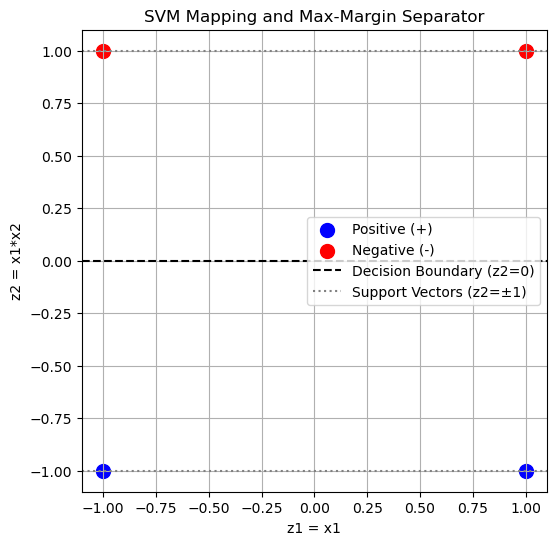

In [9]:
#Q6 Construct a support vector machine that computes the kernel function. Use
#four values of +1 and -1 for both inputs and outputs:
#[−1, −1] (negative)
#[−1, +1] (positive)
#[+1, −1] (positive)
#[+1, +1] (negative).
#Map the input [x1, x2] into a space consisting of x1 and x1x2. Draw the four input points in this
#space, and the maximal margin separator. What is the margin? 【To be consistent with our
#lecture notes, margin is defined as the distance from the middle way/hyperplane to either
#support vectors. 】
import matplotlib.pyplot as plt

# Data points in transformed space (z1 = x1, z2 = x1*x2)
points = {
    '(-1,-1)': (-1, 1),   # negative
    '(-1,+1)': (-1, -1),  # positive
    '(+1,-1)': (1, -1),   # positive
    '(+1,+1)': (1, 1)     # negative
}

# Separate by class
negatives = [v for k, v in points.items() if k in ['(-1,-1)', '(+1,+1)']]
positives = [v for k, v in points.items() if k in ['(-1,+1)', '(+1,-1)']]

# Plot
plt.figure(figsize=(6,6))
plt.scatter([x for x, y in positives], [y for x, y in positives], color='blue', label='Positive (+)', s=100)
plt.scatter([x for x, y in negatives], [y for x, y in negatives], color='red', label='Negative (-)', s=100)

# Draw separator z2 = 0
plt.axhline(0, color='black', linestyle='--', label='Decision Boundary (z2=0)')
plt.axhline(1, color='gray', linestyle=':', label='Support Vectors (z2=±1)')
plt.axhline(-1, color='gray', linestyle=':')

# Labels and aesthetics
plt.xlabel('z1 = x1')
plt.ylabel('z2 = x1*x2')
plt.title('SVM Mapping and Max-Margin Separator')
plt.legend()
plt.grid(True)
plt.show()
